# Soustraction Spectrale
### Outils
- Audacity
- MUSDB18-HQ (Format: .wav ; Encodage: signed 16-bit PCM) compatible avec soundfile (cf https://libsndfile.github.io/libsndfile/formats.html)

### Remarques

- Nous travaillons avec des fréquences d'echantillonage 44100 Hz equivalents aux CD (cf MUSDB18)
- Nous fixons la graine (0) afin que les resultats soient reproductibles
- Les DSP sont en decibels dB pour le reste de ce notebook (entrees et sorties)
### Importation des librairies et fichiers audio

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os
import soundfile as sf
from scipy.signal import stft, istft
np.random.seed(0)
fs_CD=44100

In [76]:
son1,samplerate=sf.read('../../data/son1.wav')
print(samplerate)
son2,samplerate=sf.read('../../data/son2.wav')
print(samplerate)
son3,samplerate=sf.read('../../data/son3.wav')
print(samplerate)

44100
44100
44100


### Fonctions de mesure et visualisation

In [60]:
def SNR(u,v):
    Pu,Pv=np.sum(u**2)/len(u),np.sum(v**2)/len(v)
    return 10*np.log10(Pu/Pv)

def signal(x,fs,show=False):
    '''
    Retourne le signal avec son axe temporelle
    --- In ---
    x : signal (ndarray)
    fs : frequence d'echantillonage (float)
    show : trace le signal temporel (bool)
    --- Out ---
    t : axe temporel (ndarray)
    x : signal (ndarray)
    '''
    t=np.arange(len(x))/fs
    if show:
        plt.plot(t,x)
        plt.title('Signal')
        plt.ylabel('Amplitude')
        plt.xlabel('Time [sec]')
        plt.show()
    return t,x

def signal_power(x):
    return np.sum(x**2)/len(x)

def periodogram(x, fs: float,show=False):
    '''
    Periodogramme d'un signal entree
    --- In ---
    x : signal (ndarray)
    fs : frequence d'echantillonage (float)
    show : trace le periodogramme (bool)
    --- Out ---
    f : axe frequentiel (ndarray)
    Pgram : Densite spectrale DSP (ndarray)
    '''
    x_hat=np.fft.fft(x)
    f=np.fft.fftfreq(len(x),1/fs)
    Pgram=(np.abs(x_hat)**2)/(len(x)*fs)
    if show:
        plt.plot(f,Pgram,label='Spectral Density')
        plt.title('Periodogram')
        plt.ylabel('Spectral Density')
        plt.xlabel('Frequency [Hz]')
        plt.legend()
        plt.show()
    return f, Pgram
    
def spectrogram(x, fs: float, show=False):
    '''
    Trace le spectrogramme du signal d'entree
    --- In ---
    x : signal (ndarray)
    fs : frequence d'echantillonage (float)
    show : trace le periodogramme (bool)
    --- Out ---
    t : axe temporel
    f : axe frequentiel
    Sgram : de
    '''
    f,t,Sgram=stft(x,fs,nperseg=1000)
    if show:
        plt.pcolormesh(t, f, np.abs(Sgram))
        plt.title('STFT Magnitude')
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time Index')
        plt.colorbar()
        plt.show()
    return t,f,Sgram

def white_noise(N: int, fs: float, mu: float, sigma: float,seed=0,show=False):
    '''
    Cree un signal 'bruit blanc'
    --- In ---
    N : longueur du signal (int)
    fs : frequence d'echantillonage (float)
    mu : moyenne du bruit (float)
    sigma : ecart-type du bruit (float)
    seed : graine np.random (int)
    --- Out ---
    noise : signal bruite (ndarray)
    '''
    np.random.seed(seed)
    noise=np.random.normal(mu,sigma,N)
    if show:
        signal(noise,fs,True)
    return noise

def add_white_noise(x, fs: float, target_SNR: float, seed=0, show=False):
    '''
    Ajoute du bruit blanc au signal jusqu'a obtenir la DSP totale recherchee.
    --- In ---
    x : signal (ndarray)
    fs : frequence d'echantillonage (float)
    target_SNR : DSP recherchee en sortie (float)
    show : trace le signal en sortie (bool)
    --- Out ---
    x_b : signal bruite (ndarray)
    '''
    target_sigma=(signal_power(x)*10**-(target_SNR/10))**.5
    x_b=x+white_noise(len(x),fs,0,target_sigma,seed,False)
    if show:
        signal(x_b,fs,True)
    return x_b

### Soustraction a bruit blanc

#### son1.wav

(array([0.00000000e+00, 2.26757370e-05, 4.53514739e-05, ...,
        2.26689342e-01, 2.26712018e-01, 2.26734694e-01], shape=(10000,)),
 array([17.64052346,  4.00157208,  9.78737984, ...,  5.16872179,
        -0.32920693, 12.98111432], shape=(10000,)))

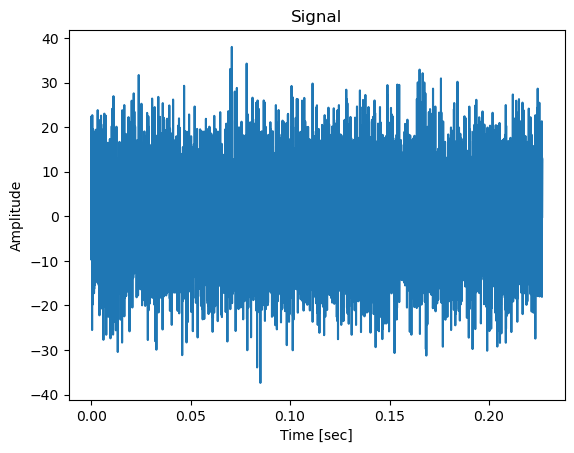

In [40]:
white_1=white_noise(10000,fs_CD,0,10)
signal(white_1,fs_CD,True)

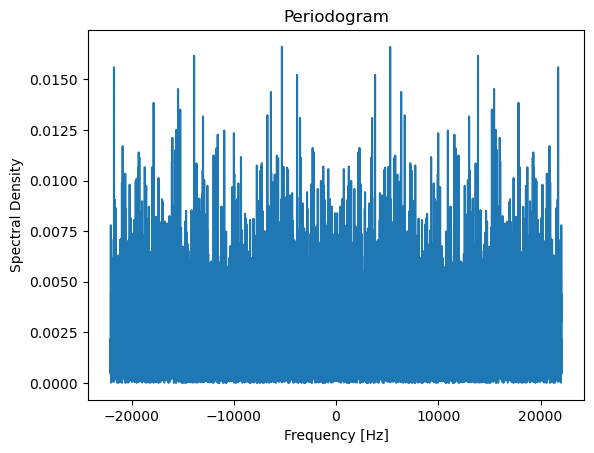

In [41]:
#Visualisation de la Periode
f1,Pgram_1=periodogram(white_1,fs_CD,True)

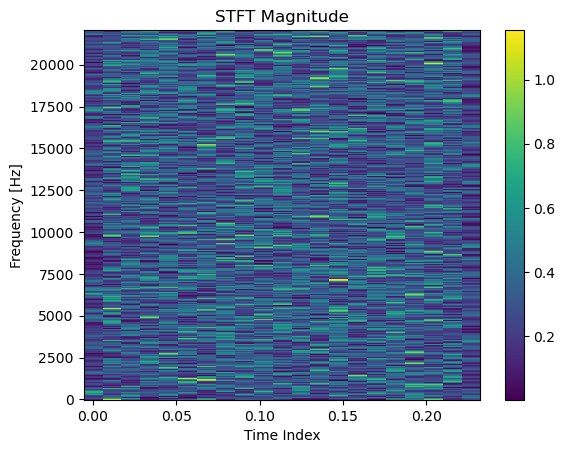

In [61]:
#Visualisation du Spectre
t,f,Sgram_b=spectrogram(white_1,fs_CD,True)

### Signal 1 - 

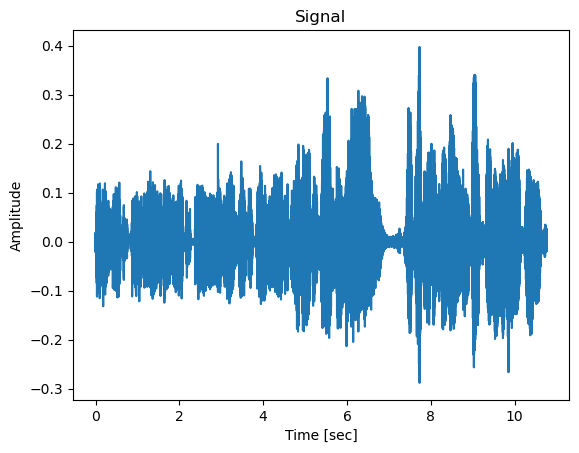

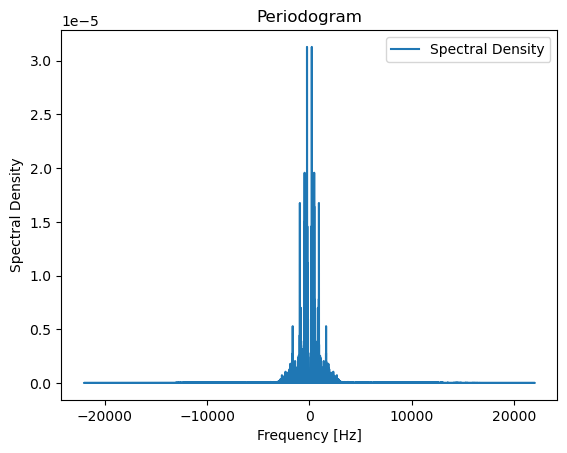

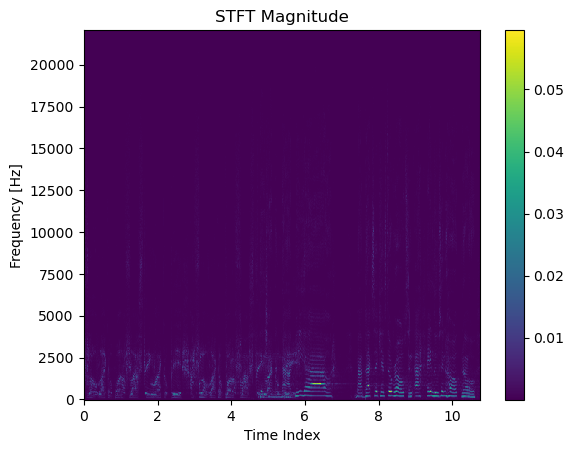

In [66]:
#Visualisations du signal propre
t1,x1=signal(son1,fs_CD,True)
f1,Pgram1=periodogram(son1,fs_CD,True)
t1,f1,Sgram1=spectrogram(son1,fs_CD,True)

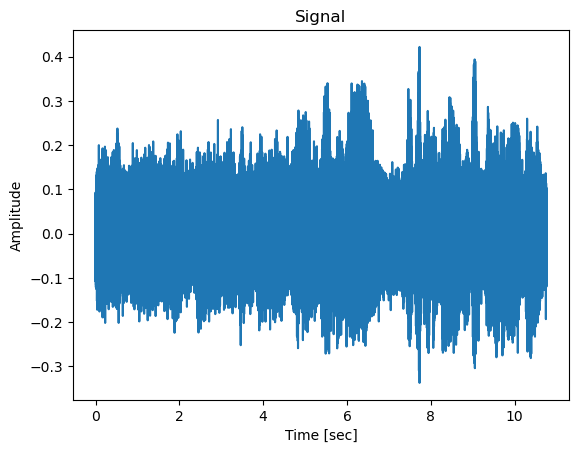

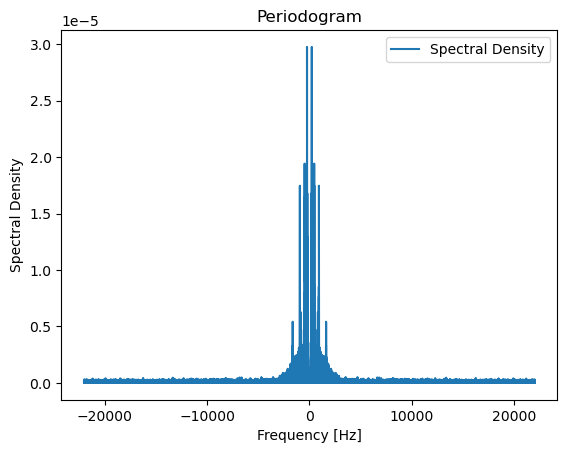

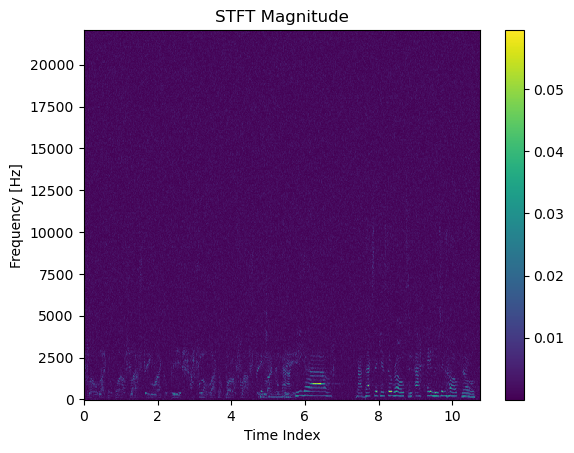

In [74]:
#Visualisations du signal bruite blanc
tSNR=1
son1_b=add_white_noise(son1,fs_CD,tSNR,0,True)
f2,Pgram2=periodogram(son1_b,fs_CD,True)
t2,f2,Sgram2=spectrogram(son1_b,fs_CD,True)


In [75]:
#---Ne pas executer temporairement---
#Ecriture du son bruite
#sf.write('../../data/son1 bruite.wav',son1_b,44100)

### Signal 2 - 

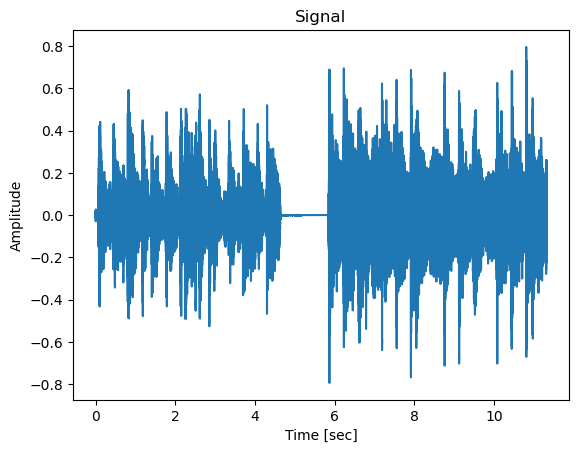

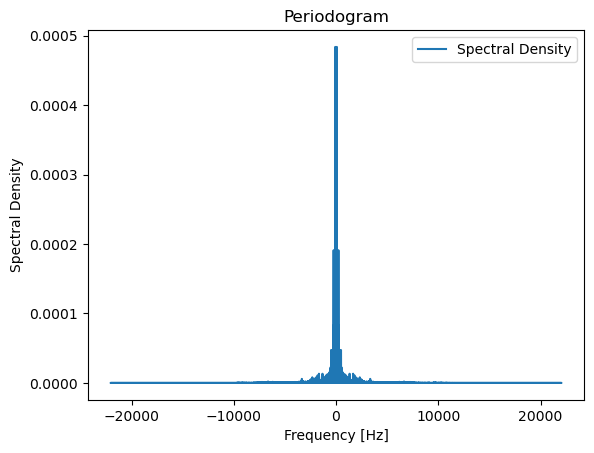

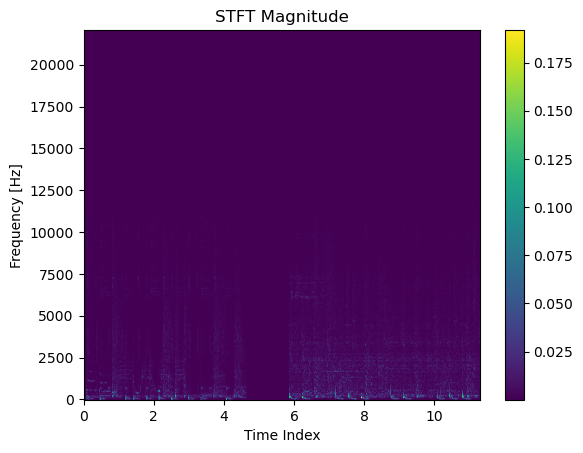

In [78]:
#Visualisations du signal propre
t1,x1=signal(son2,fs_CD,True)
f1,Pgram1=periodogram(son2,fs_CD,True)
t1,f1,Sgram1=spectrogram(son2,fs_CD,True)

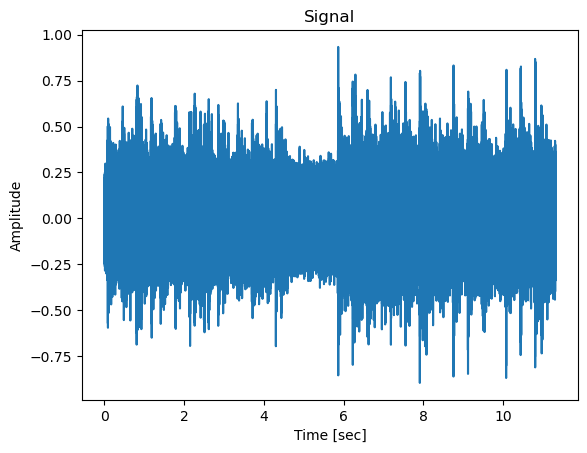

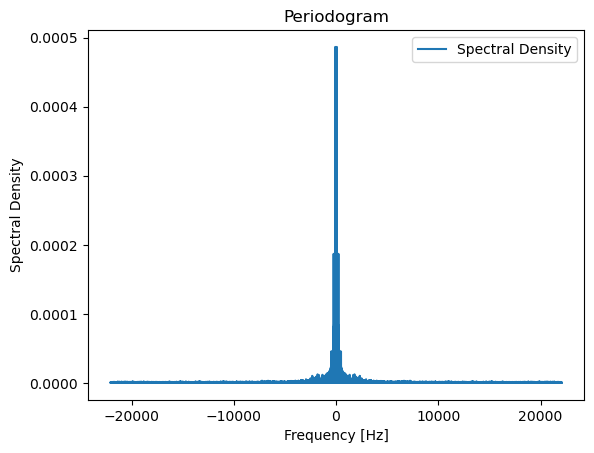

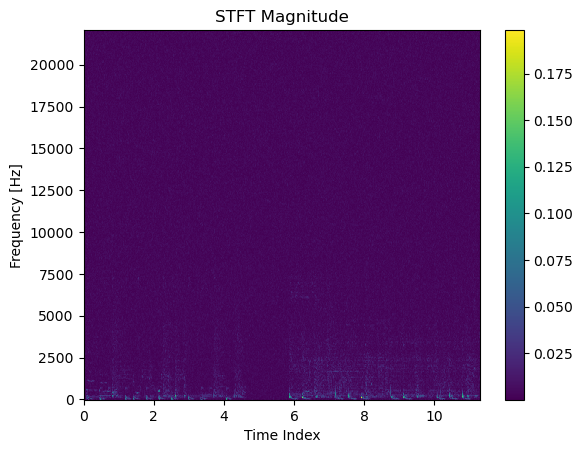

In [80]:
#Visualisations du signal bruite blanc
tSNR=1
son2_b=add_white_noise(son2,fs_CD,tSNR,0,True)
f2,Pgram2=periodogram(son2_b,fs_CD,True)
t2,f2,Sgram2=spectrogram(son2_b,fs_CD,True)

In [87]:
#---Ne pas executer temporairement---
#Ecriture du son bruite
#sf.write('../../data/son2 bruite.wav',son2_b,44100)

### Signal 3 -

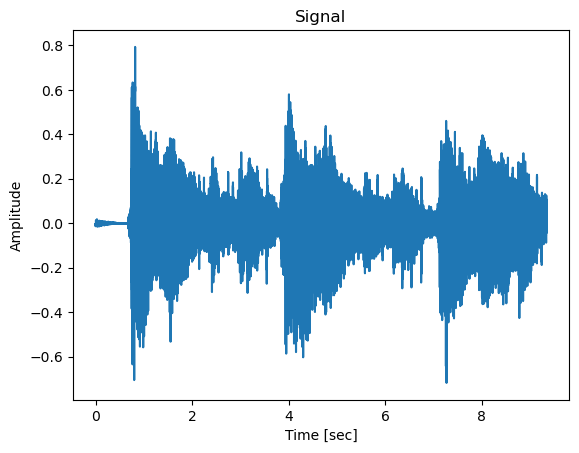

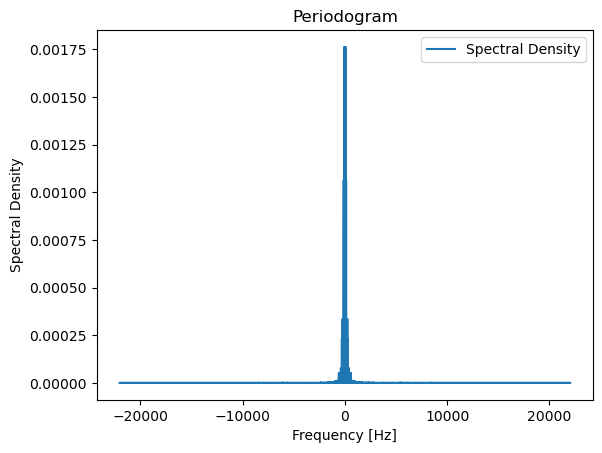

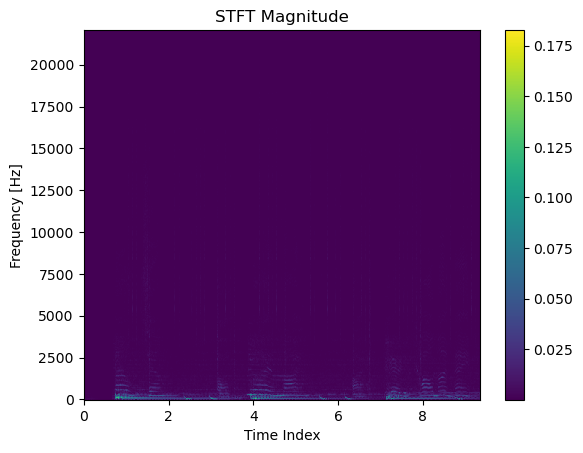

In [84]:
#Visualisations du signal propre
t1,x1=signal(son3,fs_CD,True)
f1,Pgram1=periodogram(son3,fs_CD,True)
t1,f1,Sgram1=spectrogram(son3,fs_CD,True)

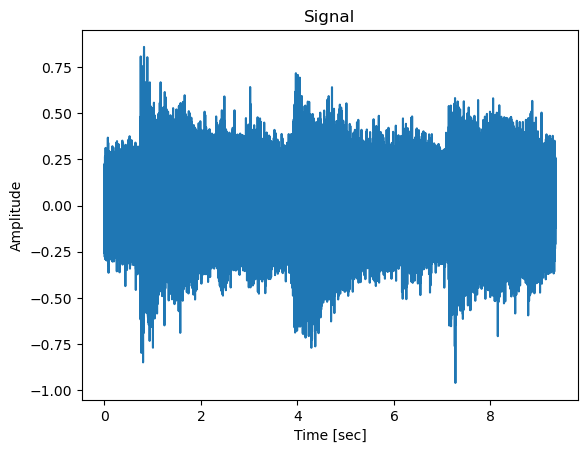

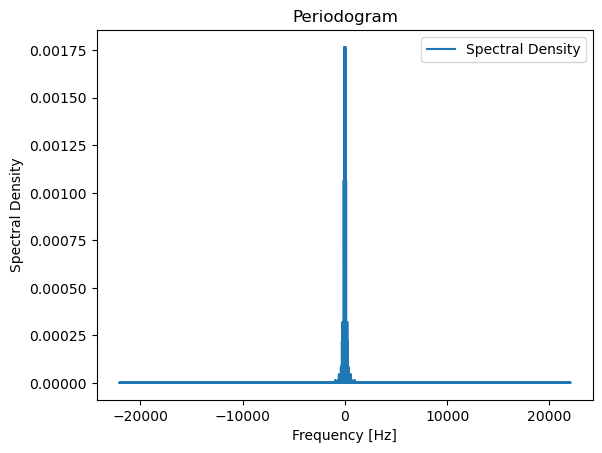

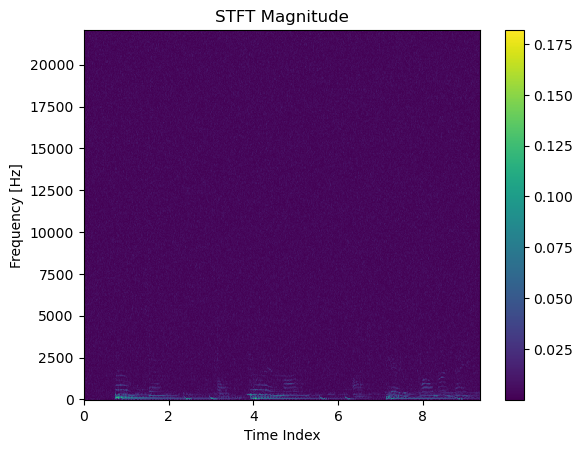

In [85]:
#Visualisations du signal bruite blanc
tSNR=1
son3_b=add_white_noise(son3,fs_CD,tSNR,0,True)
f2,Pgram2=periodogram(son3_b,fs_CD,True)
t2,f2,Sgram2=spectrogram(son3_b,fs_CD,True)

In [86]:
#---Ne pas executer temporairement---
#Ecriture du son bruite
#sf.write('../../data/son3 bruite.wav',son3_b,44100)